In [ ]:
import cv2
import mediapipe as mp
import csv
import numpy as np

# CSV files for raw and normalized data
raw_csv = open('/content/hand_landmarks_raw.csv', mode='w', newline='')
norm_csv = open('/content/hand_landmarks_normalized.csv', mode='w', newline='')

raw_writer = csv.writer(raw_csv)
norm_writer = csv.writer(norm_csv)

# Headers for 21 landmarks x 3 coordinates = 63 columns
landmark_headers = [f'{axis}_{i}' for i in range(21) for axis in ['x', 'y', 'z']]
raw_writer.writerow(['frame_id', 'hand_id'] + landmark_headers)
norm_writer.writerow(['frame_id', 'hand_id'] + landmark_headers)

# MediaPipe setup
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

cap = cv2.VideoCapture("/content/translator_video_2_unknown_61.mp4")
mode = "hands"
frame_id = 0
reference_vector = None

def normalize_landmarks(landmarks):
    wrist = landmarks[0]
    rel_landmarks = landmarks - wrist
    max_dist = np.max(np.linalg.norm(rel_landmarks, axis=1))
    norm_landmarks = rel_landmarks / max_dist if max_dist > 0 else rel_landmarks
    return norm_landmarks

def process_frame(frame, frame_id):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    landmark_stack_raw = []
    landmark_stack_norm = []

    with mp_hands.Hands(static_image_mode=False, max_num_hands=1,
                        min_detection_confidence=0.5, min_tracking_confidence=0.5) as hands:
        results = hands.process(frame_rgb)

        if results.multi_hand_landmarks:
            h, w, _ = frame.shape
            for hand_id, hand_landmarks in enumerate(results.multi_hand_landmarks):
                # mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS) # Removed drawing

                # Extract and scale
                landmarks = np.array([[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark])
                landmarks_flat = landmarks.flatten()
                raw_writer.writerow([frame_id, hand_id] + list(landmarks_flat))

                # Normalize
                landmarks_norm = normalize_landmarks(landmarks)
                norm_writer.writerow([frame_id, hand_id] + list(landmarks_norm.flatten()))

                # Save first gesture as reference
                global reference_vector
                if reference_vector is None:
                    reference_vector = landmarks_norm.flatten()
                    print("Reference gesture saved.")
                else:
                    # Compare current to reference
                    dist = np.linalg.norm(reference_vector - landmarks_norm.flatten())
                    # cv2.putText(frame, f'Diff: {dist:.4f}', (10, 60), # Removed text overlay
                    #             cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

    return frame # Still return frame even if not used for display

if not cap.isOpened():
    print("Error: Cannot open video file. Please check the file path.")
    exit()

while True:
    ret, frame = cap.read()
    if not ret:
        print("Video ended or failed to grab frame")
        break

    process_frame(frame, frame_id) # Don't need to capture the returned frame

    # cv2.putText(frame, f"Frame: {frame_id}", (10, 30), # Removed text overlay
    #             cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    # cv2.imshow("Hand Gesture Stability Check", frame) # Removed imshow

    # key = cv2.waitKey(1) & 0xFF # Removed waitKey
    # if key == ord('q'): # Removed quit key
    #     break

    frame_id += 1

cap.release()
raw_csv.close()
norm_csv.close()
# cv2.destroyAllWindows() # Removed destroyAllWindows

Reference gesture saved.
Video ended or failed to grab frame


# EDA

Loaded 30 raw frames and 30 normalized frames.

🧪 Variance in RAW coordinates (un-normalized):


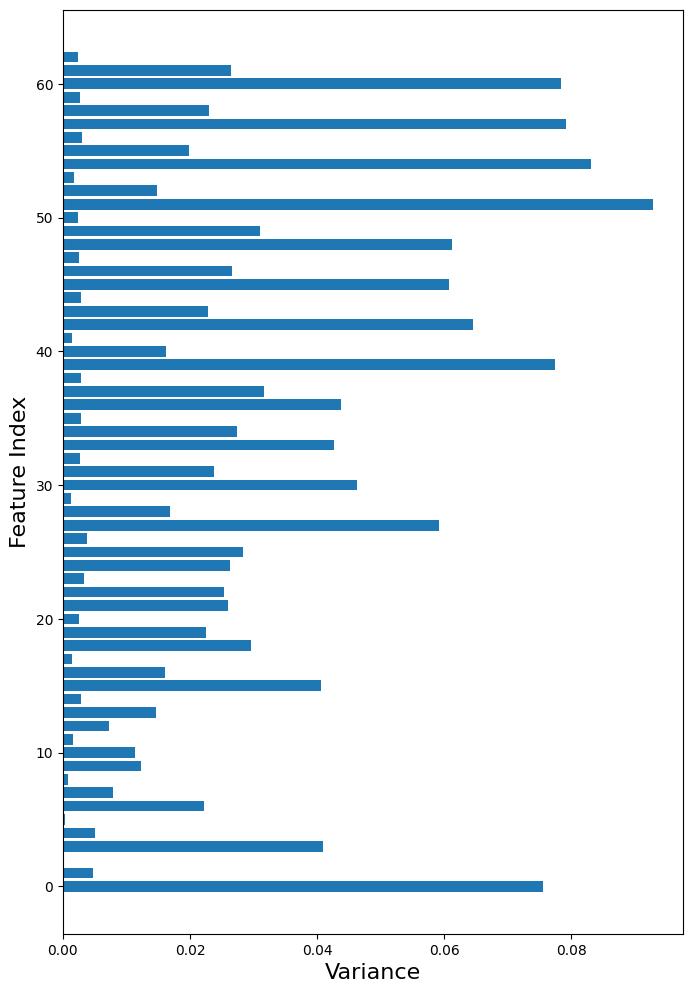

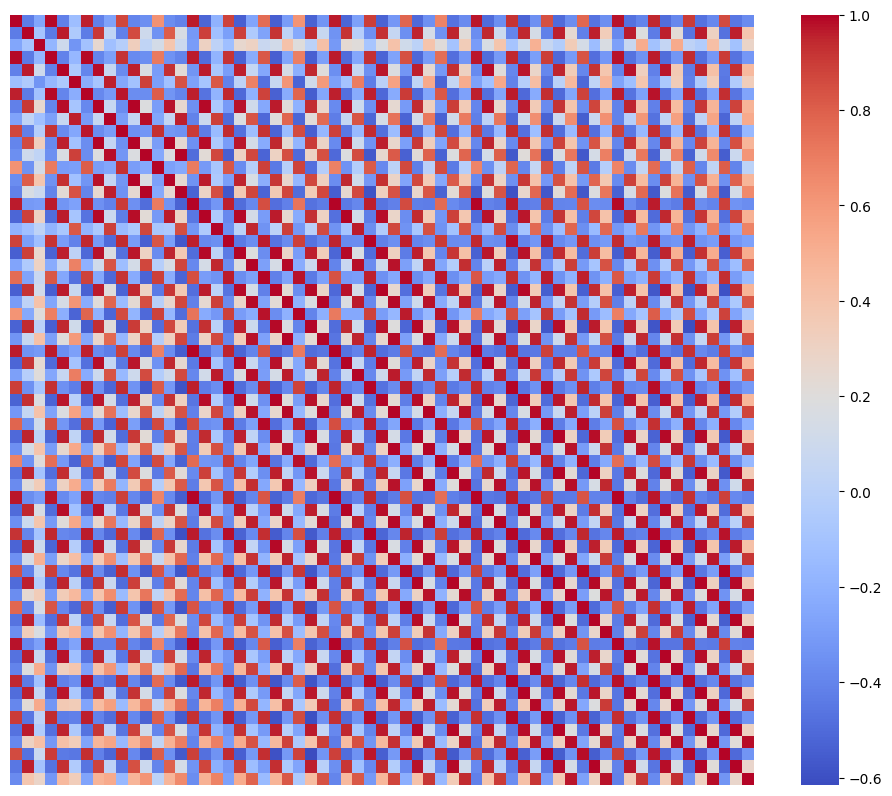

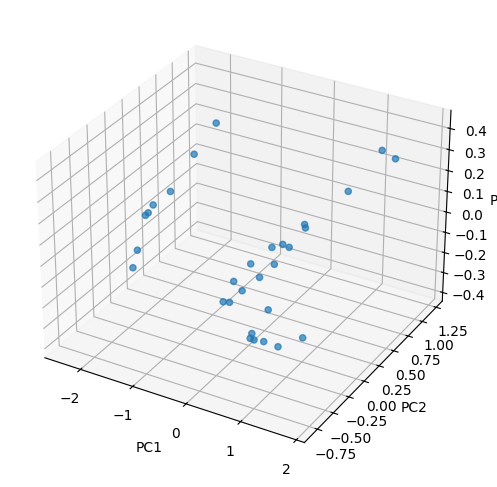


🧪 Variance in NORMALIZED coordinates (position/scale invariant):


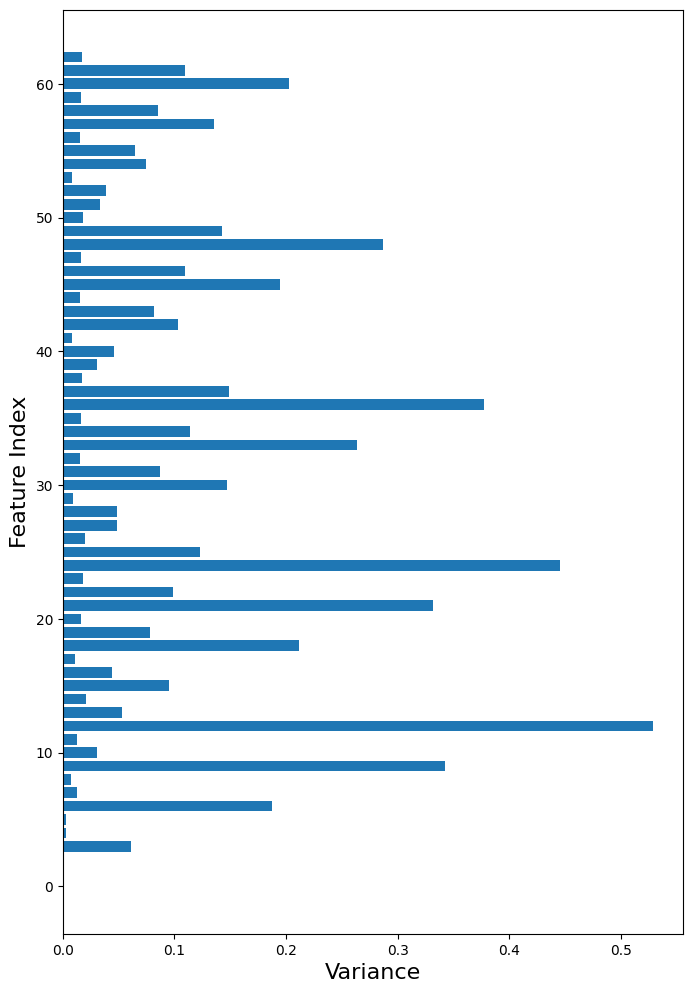

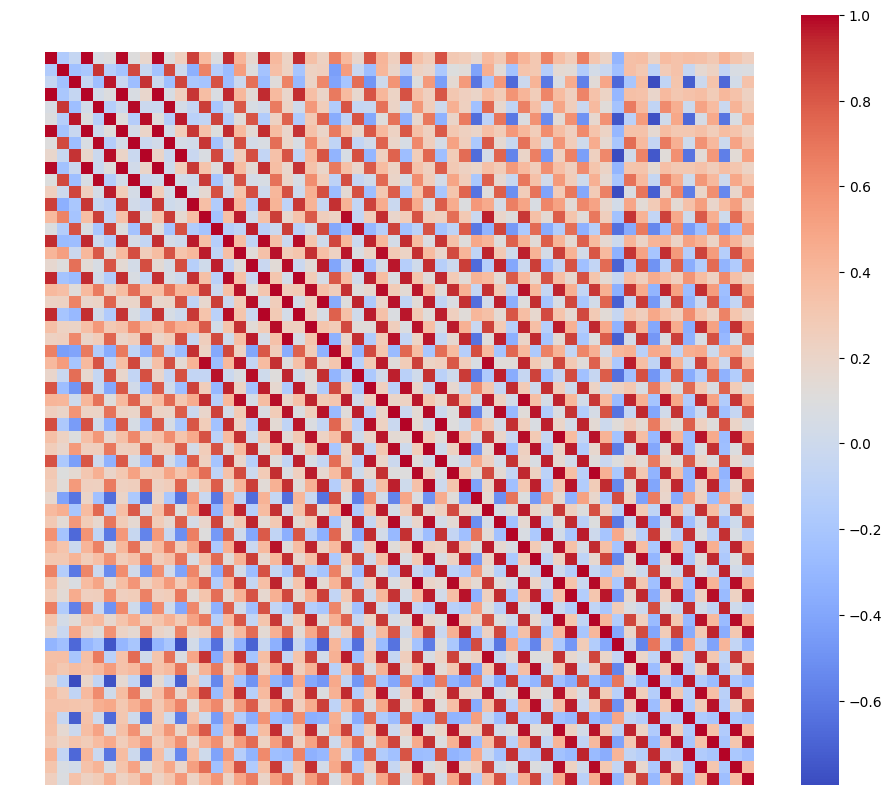

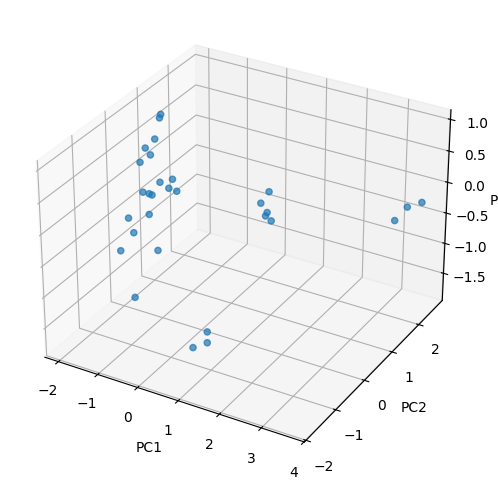


🎯 Feature selection on normalized landmarks:
Selected 60 features with variance > 0.001


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

# Load raw and normalized data
df_raw = pd.read_csv('hand_landmarks_raw.csv')
df_norm = pd.read_csv('hand_landmarks_normalized.csv')

print(f"Loaded {len(df_raw)} raw frames and {len(df_norm)} normalized frames.")

# --- ANALYSIS ---

def analyze_variance(df, title):
    df_only = df.drop(columns=['frame_id', 'hand_id'])
    variances = df_only.var()

    plt.figure(figsize=(16, 4))
    plt.bar(range(len(variances)), variances)
    plt.xlabel("Feature Index", fontsize=16)
    plt.ylabel("Variance", fontsize=16)
    plt.show()

    return variances

def correlation_heatmap(df, title):
    df_only = df.drop(columns=['frame_id', 'hand_id'])
    corr = df_only.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap='coolwarm', xticklabels=False, yticklabels=False)
    plt.show()

def run_pca(df, title, n_components=3):
    df_only = df.drop(columns=['frame_id', 'hand_id'])
    pca = PCA(n_components=n_components)
    components = pca.fit_transform(df_only)

    plt.figure(figsize=(8, 6))
    if n_components == 2:
        plt.scatter(components[:, 0], components[:, 1], alpha=0.7)
        plt.xlabel("PC1")
        plt.ylabel("PC2")
    else:
        from mpl_toolkits.mplot3d import Axes3D
        ax = plt.axes(projection='3d')
        ax.scatter(components[:, 0], components[:, 1], components[:, 2], alpha=0.7)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")
    plt.show()

    return pca

def low_variance_feature_selection(df, threshold=0.001):
    df_only = df.drop(columns=['frame_id', 'hand_id'])
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(df_only)
    mask = selector.get_support()
    selected_features = df_only.columns[mask]
    print(f"Selected {len(selected_features)} features with variance > {threshold}")
    return selected_features

# --- EXECUTE ANALYSIS ---

# Raw coordinates analysis
print("\n🧪 Variance in RAW coordinates (un-normalized):")
var_raw = analyze_variance(df_raw, "Raw")
correlation_heatmap(df_raw, "Raw")
pca_raw = run_pca(df_raw, "Raw")

# Normalized coordinates analysis
print("\n🧪 Variance in NORMALIZED coordinates (position/scale invariant):")
var_norm = analyze_variance(df_norm, "Normalized")
correlation_heatmap(df_norm, "Normalized")
pca_norm = run_pca(df_norm, "Normalized")

# Feature selection
print("\n🎯 Feature selection on normalized landmarks:")
selected_features = low_variance_feature_selection(df_norm)

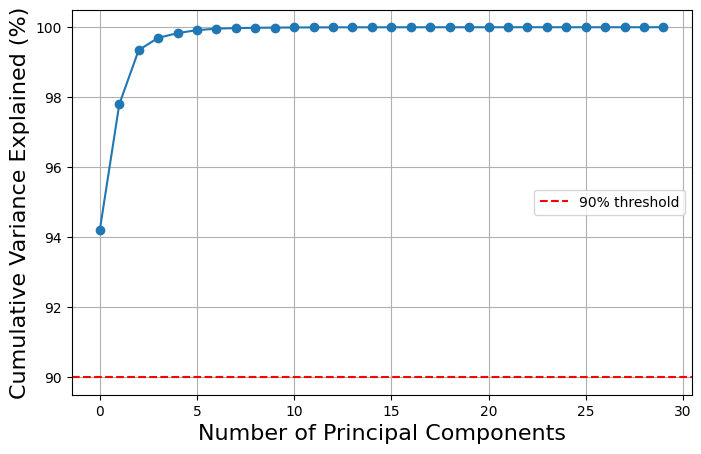

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# === 1. Load your landmark CSV ===
# Example: each row = frame, each column = landmark coordinate (63 columns)
df = pd.read_csv("hand_landmarks_normalized.csv")

# Drop non-numeric columns if needed
X = df.select_dtypes(include=[np.number]).values

# === 2. Fit PCA ===
pca = PCA().fit(X)

# === 3. Calculate cumulative explained variance ===
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100

# === 4. Plot Scree Plot ===
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.axhline(y=90, color='r', linestyle='--', label="90% threshold")
plt.xlabel('Number of Principal Components', fontsize=16)
plt.ylabel('Cumulative Variance Explained (%)', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()


🔢1. Raw Variance Plot
What it shows:

Each bar = variance of a single landmark coordinate (x/y/z of one of the 21 points).

Higher variance = feature changes more across frames (gesture motion or hand repositioning).

Low variance (near 0) = feature is nearly constant (may be noise or unused).

Interpretation:

Many raw features show high variance → sensitive to hand position, size, and movement.

Variance isn't uniform → some joints (like the wrist or fingertips) move more than others.

🔥2. Raw Correlation Heatmap
What it shows:

Red = high positive correlation (features change together)

Blue = negative correlation

Checkerboard pattern = lots of redundant features

Interpretation:

Many raw features are highly correlated due to spatial relationships (e.g. nearby joints).

Correlation doesn't mean useful — just that those features encode similar movement.

🧭3. PCA on Raw Landmarks (3D Scatter)
What it shows:

PCA reduces your 63D landmark vector to 3D (principal components).

Clusters = similar gesture shapes

Spread = variation due to hand position/scale

Interpretation:

Points are spread out — raw coordinates vary heavily based on gesture placement.

This confirms raw data is not position/scale invariant.

⚙️ 4. Normalized Variance Plot
What it shows:

Same structure as the raw plot, but uses normalized landmarks.

Most features still vary — but in a more consistent and compact range.

Interpretation:

Normalization is working — the variance range is lower.

Suggests same gesture across frames is more stable (less affected by screen position or hand size).

🔁 5. Normalized Correlation Heatmap
What it shows:

Correlation between normalized features is still present but less intense.

The diagonal pattern remains — some redundancy exists in normalized features too.

Interpretation:

Even after normalization, fingers/joints still move together, which creates correlation.

May indicate potential for feature reduction.

🔍 6. PCA on Normalized Landmarks (3D Scatter)
What it shows:

Tighter clustering than raw PCA.

Better separation = same gesture looks more consistent.

Interpretation:

Normalization made gesture space more compact and meaningful.

PCA is useful to reduce dimensions for visualization or machine learning input.

🧠 7. Feature Selection Output
🎯 Selected 60 features with variance > 0.001

What it shows:

Out of 63 normalized features (x/y/z of 21 points), 60 have non-trivial variance.

3 are likely useless (constant or near-constant) → could be dropped in model training.


❓ Do coordinates change with hand position?	✅ Yes, in raw form they change a lot.

❓ Does normalization solve that?	✅ Mostly — it removes positional and scale variation, making features more stable.

❓ Are all landmarks useful?	⚠️ No — some have low variance or are redundant.

❓ What should I use for ML?	✅ Normalized + filtered features (high variance, low correlation). Use PCA or manual selection.

In [ ]:
pip install dtw-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.7/801.7 kB 38.7 MB/s eta 0:00:00


In [ ]:
!pip install fastdtw


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp311-cp311-linux_x86_64.whl size=542083 sha256=f05acd5f6377c1f5fb893f0db8807a364488acc0e12cf5e1dabfcb60b6859e84
  Stored in directory: /root/.cache/pip/wheels/5c/8a/f6/fd3df9a9714677410a5ccbf3ca519e66db4a54a1c46ea95332
Successfully built fastdtw


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt

# --- Landmark processing ---

def extract_landmark_sequence(video_path, max_frames=300):
    mp_hands = mp.solutions.hands
    sequence = []

    cap = cv2.VideoCapture(video_path)
    frame_idx = 0

    with mp_hands.Hands(static_image_mode=False, max_num_hands=1,
                        min_detection_confidence=0.5, min_tracking_confidence=0.5) as hands:
        while len(sequence) < max_frames:
            ret, frame = cap.read()
            if not ret:
                print(f"❌ End of video or can't read frame at {frame_idx}")
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = hands.process(frame_rgb)

            if result.multi_hand_landmarks:
                hand_landmarks = result.multi_hand_landmarks[0]
                landmarks = np.array([[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark])
                norm = normalize_landmarks(landmarks)
                sequence.append(norm.flatten())
            else:
                print(f"⚠️ No hand detected in frame {frame_idx}")

            frame_idx += 1

        cap.release()

    return np.array(sequence)

def normalize_landmarks(landmarks):
    wrist = landmarks[0]
    rel = landmarks - wrist
    max_dist = np.max(np.linalg.norm(rel, axis=1))
    return rel / max_dist if max_dist > 0 else rel

# --- DTW comparison ---

def compare_sequences_dtw(seq1, seq2):
    distance, path = fastdtw(seq1, seq2, dist=euclidean)
    return distance, path

# --- MAIN ---

user_video = "/content/user_video_8_HSTechk_14.mp4"
translator_video = "/content/translator_video_7_jhasanov_11.mp4"

print("⏳ Extracting user video landmarks...")
seq_user = extract_landmark_sequence(user_video)
print(f"✅ User sequence length: {len(seq_user)}")

print("⏳ Extracting translator video landmarks...")
seq_translator = extract_landmark_sequence(translator_video)
print(f"✅ Translator sequence length: {len(seq_translator)}")

if len(seq_user) == 0 or len(seq_translator) == 0:
    print("❌ One or both sequences are empty. Check hand detection or video paths.")
else:
    print("🔁 Comparing with DTW...")
    dtw_distance, path = compare_sequences_dtw(seq_user, seq_translator)
    print(f"🎯 DTW Distance: {dtw_distance:.4f}")

    # Optional: visualize the alignment path
    user_indices, translator_indices = zip(*path)
    plt.plot(user_indices, translator_indices)
    plt.title("DTW Alignment Path")
    plt.xlabel("User Frames")
    plt.ylabel("Translator Frames")
    plt.grid()
    plt.show()


⏳ Extracting user video landmarks...
❌ End of video or can't read frame at 0
✅ User sequence length: 0
⏳ Extracting translator video landmarks...
❌ End of video or can't read frame at 0
✅ Translator sequence length: 0
❌ One or both sequences are empty. Check hand detection or video paths.


In [ ]:
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

def plot_dtw_alignment_overlay(seq1, seq2, path, title="Warped Landmark Sequences"):
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111)

    for i, (i1, i2) in enumerate(zip(*path)):
        y1 = np.linalg.norm(seq1[i1])  # Norm of vector = gesture intensity
        y2 = np.linalg.norm(seq2[i2])
        ax.plot([i1, i2], [y1, y2], color='gray', alpha=0.3)

    ax.plot([np.linalg.norm(f) for f in seq1], label='User', color='blue')
    ax.plot([np.linalg.norm(f) for f in seq2], label='Translator', color='green')
    ax.set_title(title)
    ax.set_xlabel("Frame Index")
    ax.set_ylabel("Motion Intensity (L2 Norm)")
    ax.legend()
    plt.grid()
    plt.show()

def plot_speed_profile(seq, label):
    speed = [np.linalg.norm(seq[i] - seq[i - 1]) for i in range(1, len(seq))]
    plt.plot(speed, label=label)

def plot_cost_matrix(seq1, seq2):
    cost_matrix = cdist(seq1, seq2, metric='euclidean')
    plt.figure(figsize=(8, 6))
    plt.imshow(cost_matrix, origin='lower', cmap='viridis', aspect='auto')
    plt.colorbar(label="Euclidean Distance")
    plt.title("DTW Cost Matrix (Unwarped)")
    plt.xlabel("Translator Frames")
    plt.ylabel("User Frames")
    plt.show()


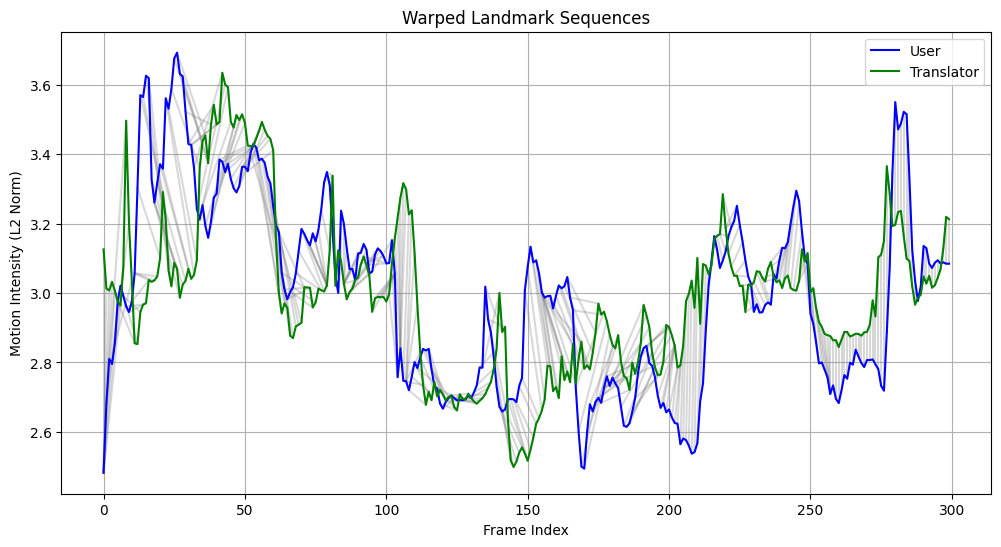

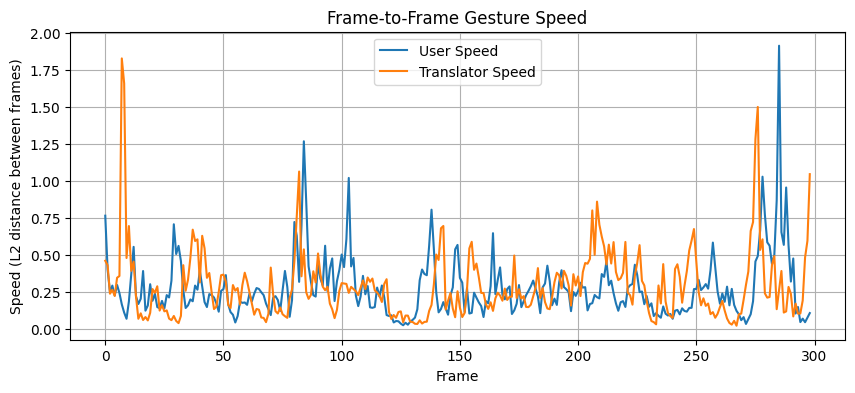

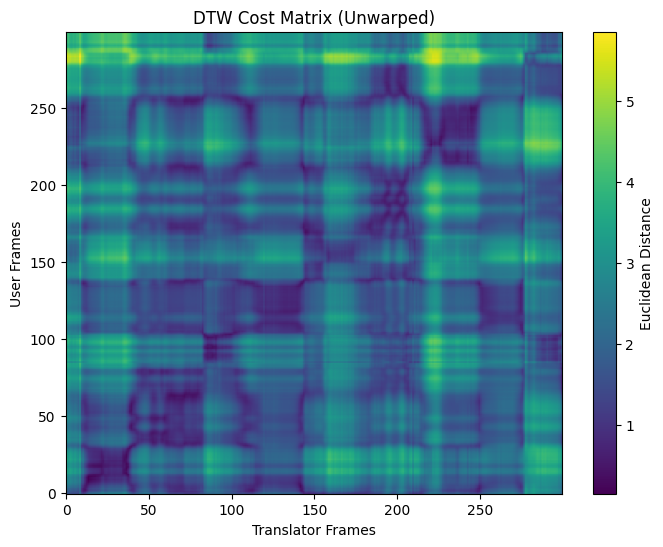

In [ ]:
# Plot motion intensity comparison with DTW path
plot_dtw_alignment_overlay(seq_user, seq_translator, path)

# Plot speed profile
plt.figure(figsize=(10, 4))
plot_speed_profile(seq_user, "User Speed")
plot_speed_profile(seq_translator, "Translator Speed")
plt.title("Frame-to-Frame Gesture Speed")
plt.xlabel("Frame")
plt.ylabel("Speed (L2 distance between frames)")
plt.legend()
plt.grid()
plt.show()

# Plot cost matrix
plot_cost_matrix(seq_user, seq_translator)


In [ ]:
def plot_cost_matrix_with_path(seq1, seq2, path):
    from scipy.spatial.distance import cdist
    cost_matrix = cdist(seq1, seq2, metric='euclidean')

    plt.figure(figsize=(8, 6))
    plt.imshow(cost_matrix.T, origin='lower', cmap='viridis', aspect='auto')
    plt.colorbar(label="Euclidean Distance")
    plt.title("DTW Cost Matrix with Alignment Path")
    plt.xlabel("User Frames")
    plt.ylabel("Translator Frames")

    # Overlay the warping path
    plt.plot(path[0], path[1], color='red', linewidth=1.0, label='DTW Path')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


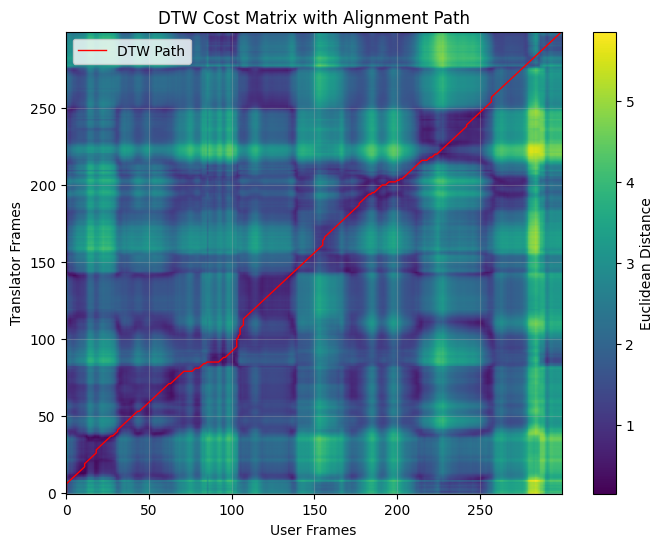

In [ ]:
plot_cost_matrix_with_path(seq_user, seq_translator, path)


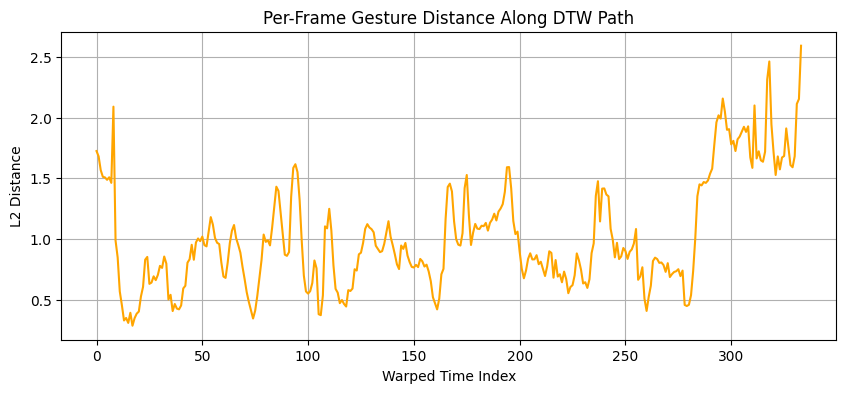

In [ ]:
def plot_per_frame_difference(seq1, seq2, path):
    diffs = [np.linalg.norm(seq1[i] - seq2[j]) for i, j in zip(*path)]
    plt.figure(figsize=(10, 4))
    plt.plot(diffs, color='orange')
    plt.title("Per-Frame Gesture Distance Along DTW Path")
    plt.xlabel("Warped Time Index")
    plt.ylabel("L2 Distance")
    plt.grid()
    plt.show()
plot_per_frame_difference(seq_user, seq_translator, path)


In [ ]:
MATCH_THRESHOLD = 1.5  # You can tune this based on DTW values


In [ ]:
import cv2
import numpy as np

def play_dtw_aligned_videos(user_video_path, translator_video_path, path, seq_user, seq_translator, threshold=1.5):
    cap_user = cv2.VideoCapture(user_video_path)
    cap_translator = cv2.VideoCapture(translator_video_path)

    user_frames = []
    translator_frames = []

    # Preload all frames
    while True:
        ret_u, frame_u = cap_user.read()
        ret_t, frame_t = cap_translator.read()
        if not ret_u or not ret_t:
            break
        user_frames.append(frame_u)
        translator_frames.append(frame_t)

    cap_user.release()
    cap_translator.release()

    print(f"🖼 Loaded {len(user_frames)} user frames and {len(translator_frames)} translator frames.")
    print("▶ Press any key to step through aligned frames, or ESC to quit.")

    # Walk through aligned path
    for i, j in zip(*path):
        if i >= len(user_frames) or j >= len(translator_frames):
            break

        f_user = user_frames[i]
        f_trans = translator_frames[j]

        # Resize for side-by-side
        f_user = cv2.resize(f_user, (480, 360))
        f_trans = cv2.resize(f_trans, (480, 360))

        # Compute match score
        dist = np.linalg.norm(seq_user[i] - seq_translator[j])
        match_status = "MATCH ✅" if dist < threshold else "MISMATCH ❌"
        color = (0, 255, 0) if dist < threshold else (0, 0, 255)

        # Annotate frames
        cv2.putText(f_user, f'User Frame: {i}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.putText(f_trans, f'Translator Frame: {j}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        # Combine side-by-side
        combined = np.hstack((f_user, f_trans))

        # Overlay match status
        cv2.putText(combined, f'{match_status}  |  Distance: {dist:.2f}',
                    (20, 350), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 3)

        cv2.imshow("DTW Frame Comparison", combined)
        key = cv2.waitKey(0) & 0xFF  # Wait for key press
        if key == 27:  # ESC to exit
            break

    cv2.destroyAllWindows()


In [ ]:
play_dtw_aligned_videos("/content/user_video_8_HSTechk_14.mp4",
                        "/content/translator_video_7_jhasanov_11.mp4",
                        path,
                        seq_user,
                        seq_translator,
                        threshold=1.5)


🖼 Loaded 328 user frames and 328 translator frames.
▶ Press any key to step through aligned frames, or ESC to quit.


DisabledFunctionError: cv2.imshow() is disabled in Colab, because it causes Jupyter sessions
to crash; see https://github.com/jupyter/notebook/issues/3935.
As a substitution, consider using
  from google.colab.patches import cv2_imshow
